In [2]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [3]:
# STEP 1: CREATE SAMPLE EXPENSE DATA

data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Food": [5000, 5200, 5100, 5500, 5800, 6000],
    "Travel": [2000, 2500, 2300, 2700, 3000, 3200],
    "Shopping": [3000, 3500, 3200, 4000, 4200, 4500],
    "Bills": [2500, 2600, 2550, 2700, 2800, 2900]
}

df = pd.DataFrame(data)
df.index = range(1, len(df) + 1)
print("Expense Data:\n")
print(df)

Expense Data:

  Month  Food  Travel  Shopping  Bills
1   Jan  5000    2000      3000   2500
2   Feb  5200    2500      3500   2600
3   Mar  5100    2300      3200   2550
4   Apr  5500    2700      4000   2700
5   May  5800    3000      4200   2800
6   Jun  6000    3200      4500   2900


In [4]:
# STEP 2: TOTAL MONTHLY EXPENSE

df["Total_Expense"] = (
    df["Food"] +
    df["Travel"] +
    df["Shopping"] +
    df["Bills"]
)

print("\nTotal Monthly Expense:\n")
print(df[["Month", "Total_Expense"]])


Total Monthly Expense:

  Month  Total_Expense
1   Jan          12500
2   Feb          13800
3   Mar          13150
4   Apr          14900
5   May          15800
6   Jun          16600


In [5]:
# STEP 3: EXPENSE CATEGORIZATION

print("\nExpense Categories Average:\n")

categories = ["Food", "Travel", "Shopping", "Bills"]

for category in categories:
    avg = df[category].mean()
    print(f"{category} Average Expense = ₹{avg:.2f}")


Expense Categories Average:

Food Average Expense = ₹5433.33
Travel Average Expense = ₹2616.67
Shopping Average Expense = ₹3733.33
Bills Average Expense = ₹2675.00


In [6]:
# STEP 4: MONTHLY EXPENSE PREDICTION

# months ko numeric value me convert karega
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)

# Target values
y = df["Total_Expense"]

# Train Model
model = LinearRegression()
model.fit(X, y)

# Predict Next Month (July = 7)
next_month = np.array([[7]])

predicted_expense = model.predict(next_month)

print("\nPredicted Expense for Next Month (July):")
print(f"₹{predicted_expense[0]:.2f}")


Predicted Expense for Next Month (July):
₹17283.33


In [7]:
# STEP 5: OVERSPENDING ALERT


average_expense = df["Total_Expense"].mean()

last_month_expense = df["Total_Expense"].iloc[-1]

print("\nOverspending Analysis:")

if last_month_expense > average_expense:
    print(" ALERT: You are overspending!")
else:
    print(" Your spending is under control.")


Overspending Analysis:
 ALERT: You are overspending!


In [8]:

# STEP 6: SAVINGS SUGGESTIONS


print("\nSavings Suggestions:\n")

highest_category = df[categories].mean().idxmax()

print(f"Highest Spending Category: {highest_category}")

if highest_category == "Shopping":
    print("Suggestion: Reduce unnecessary shopping.")
elif highest_category == "Food":
    print("Suggestion: Try home-made meals more often.")
elif highest_category == "Travel":
    print("Suggestion: Use public transport to save money.")
elif highest_category == "Bills":
    print("Suggestion: Reduce electricity and internet usage.")


Savings Suggestions:

Highest Spending Category: Food
Suggestion: Try home-made meals more often.


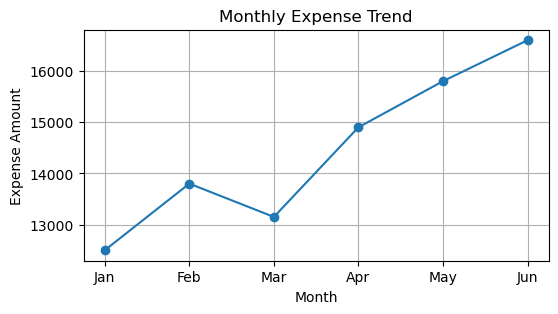

In [9]:

# STEP 7: VISUALIZATION


plt.figure(figsize=(6,3))

plt.plot(df["Month"], df["Total_Expense"], marker='o')

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Expense Amount")

plt.grid(True)

plt.show()

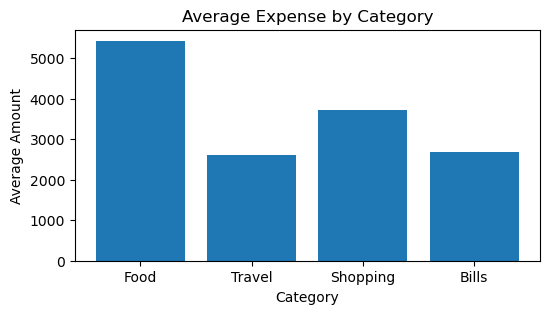

In [10]:
# STEP 8: CATEGORY-WISE VISUALIZATION


category_totals = df[categories].mean()

plt.figure(figsize=(6,3))

plt.bar(category_totals.index, category_totals.values)

plt.title("Average Expense by Category")
plt.xlabel("Category")
plt.ylabel("Average Amount")

plt.show()

In [11]:
# FINAL Result 

print(f"Average Monthly Expense: ₹{average_expense:.2f}")

print(f"Predicted Next Month Expense: ₹{predicted_expense[0]:.2f}")

print(f"Highest Spending Category: {highest_category}")

Average Monthly Expense: ₹14458.33
Predicted Next Month Expense: ₹17283.33
Highest Spending Category: Food
